# Eigendecomposition and SVD Applications

Notebook ini merangkum Chapter 15 dari *Practical Linear Algebra for Data Science*. Chapter ini membahas aplikasi **eigendecomposition** dan **Singular Value Decomposition (SVD)** dalam data science, khususnya untuk **Principal Component Analysis (PCA)**, **Linear Discriminant Analysis (LDA)**, **low-rank approximation**, dan **image denoising**.

Pembahasan dibuat mengikuti format Chapter 11–14: ada tujuan pembelajaran, ringkasan chapter, struktur pembahasan, penjelasan teori per bagian, rumus matematis yang relevan, kode inti, ringkasan konsep, dan kesimpulan.

## Tujuan Pembelajaran

- Memahami PCA sebagai metode pencarian basis vector baru yang memaksimalkan variance.
- Menjelaskan hubungan PCA dengan eigendecomposition covariance matrix.
- Mengimplementasikan PCA secara manual menggunakan eigendecomposition.
- Memahami PCA melalui SVD pada covariance matrix atau data matrix.
- Menjelaskan LDA sebagai metode linear untuk memisahkan kategori data.
- Memahami LDA melalui generalized eigendecomposition.
- Membuat within-class covariance dan between-class covariance.
- Memahami low-rank approximation dengan SVD untuk data compression.
- Menghitung error reconstruction dan compression ratio.
- Memahami denoising menggunakan SVD dengan menghapus komponen yang dianggap noise.

## Ringkasan Chapter

Chapter ini menunjukkan beberapa aplikasi utama eigendecomposition dan SVD dalam data science. Fokusnya adalah memperlihatkan bahwa metode yang tampak kompleks seperti PCA, LDA, compression, dan denoising sebenarnya dibangun dari konsep linear algebra yang sudah dibahas pada chapter sebelumnya.

Bagian pertama membahas PCA. Tujuan PCA adalah mencari basis vector baru yang membuat linear weighted combination dari fitur data memiliki variance sebesar mungkin. Dalam PCA, data diproyeksikan ke basis baru yang merupakan orthogonal rotation dari basis awal. Secara matematis, PCA dapat diselesaikan melalui eigendecomposition covariance matrix. Eigenvectors menjadi weights untuk fitur, sedangkan eigenvalues menunjukkan variance dari masing-masing principal component.

Bagian kedua membahas LDA. Jika PCA mencari arah dengan variance terbesar, LDA mencari arah yang paling baik memisahkan kategori data. LDA memaksimalkan rasio antara between-category covariance dan within-category covariance. Solusi LDA diperoleh melalui generalized eigendecomposition pada dua covariance matrices.

Bagian ketiga membahas low-rank approximation melalui SVD. Matrix atau image dapat direkonstruksi menggunakan sebagian singular vectors dan singular values. Jika hanya komponen awal yang digunakan, data dapat dikompresi. Namun, kualitas hasil bergantung pada struktur data. Image nyata biasanya membutuhkan lebih banyak komponen dibanding smooth noise matrix.

Bagian terakhir membahas SVD untuk denoising. Prinsipnya mirip dengan low-rank approximation, tetapi komponen yang dihapus dipilih karena dianggap merepresentasikan noise atau artifact. Chapter memberi contoh noise berupa sine grating yang ditambahkan ke image, lalu komponen SVD tertentu dihilangkan untuk mengurangi noise.

## Struktur Pembahasan Chapter

| Bagian | Inti Pembahasan |
|---|---|
| PCA Using Eigendecomposition and SVD | PCA mencari basis baru yang memaksimalkan variance data. |
| The Math of PCA | PCA diturunkan menjadi eigendecomposition covariance matrix. |
| The Steps to Perform PCA | PCA dilakukan dengan covariance matrix, eigendecomposition, sorting, component scores, dan variance explained. |
| PCA via SVD | PCA dapat dilakukan melalui SVD covariance matrix atau SVD data matrix. |
| Linear Discriminant Analysis | LDA mencari arah yang memaksimalkan separasi antar kategori. |
| LDA Math | LDA diselesaikan sebagai generalized eigendecomposition. |
| Low-Rank Approximations via SVD | SVD digunakan untuk reconstruction, compression, dan approximation. |
| SVD for Denoising | Komponen SVD tertentu dihapus jika merepresentasikan noise. |

## Persiapan Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.linalg import eigh
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

try:
    from sklearn.decomposition import PCA
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    from sklearn.model_selection import train_test_split
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

np.random.seed(2024)

## PCA Using Eigendecomposition and SVD

Tujuan PCA adalah mencari basis vector baru untuk dataset sehingga hubungan linear antar variable lebih sejajar dengan basis vector tersebut. Dalam dataset dengan $M$ fitur, setiap data point dapat dipandang sebagai koordinat dalam ruang $\mathbb{R}^M$.

PCA berusaha mencari arah baru yang menangkap variance terbesar. Asumsi utama PCA adalah:

> variance = relevance

Artinya, arah dengan variance lebih besar dianggap lebih penting dalam menjelaskan struktur data.

## The Math of PCA

PCA menggabungkan konsep statistik variance dan konsep linear algebra linear weighted combination. Misalkan:

- $X$ = data matrix yang sudah mean-centered
- $w$ = vector weights

Tujuan PCA adalah mencari $w$ sehingga weighted combination $Xw$ memiliki variance maksimum.

### Rumus Awal PCA

$$
\lambda = \|Xw\|^2
$$

Namun, jika $w$ dibuat sangat besar, nilai $\lambda$ juga akan membesar. Karena itu, perlu normalisasi dengan norm dari weights:

$$
\lambda =
\frac{\|Xw\|^2}{\|w\|^2}
$$

Norm tersebut dapat ditulis sebagai dot product:

$$
\lambda =
\frac{w^TX^TXw}{w^Tw}
$$

Jika:

$$
C = X^TX
$$

maka:

$$
\lambda =
\frac{w^TCw}{w^Tw}
$$

Keterangan:

- $C$ = covariance-related matrix
- $w$ = weights vector
- $\lambda$ = variance dari component

## PCA sebagai Eigendecomposition

Chapter menunjukkan bahwa solusi PCA mengarah ke eigendecomposition covariance matrix.

### Rumus PCA Eigenvalue Problem

$$
CW = W\Lambda
$$

Keterangan:

- $C$ = covariance matrix
- $W$ = matrix eigenvectors atau principal component weights
- $\Lambda$ = diagonal matrix eigenvalues
- Eigenvectors menjadi weights untuk data features
- Eigenvalues menunjukkan variance pada masing-masing component

Karena covariance matrix bersifat symmetric, principal components yang dihasilkan PCA bersifat orthogonal.

## Langkah-Langkah PCA

Chapter merangkum PCA dalam lima langkah:

1. Mean-center setiap feature pada data.
2. Hitung covariance matrix.
3. Lakukan eigendecomposition covariance matrix.
4. Urutkan eigenvalues secara descending dan urutkan eigenvectors sesuai eigenvalues.
5. Hitung component scores sebagai weighted combination dari fitur data.
6. Konversi eigenvalues menjadi percent variance explained untuk interpretasi.

In [2]:
# Simulasi data 2D dengan korelasi positif
n = 1000

x = np.random.randn(n)
y = 0.7*x + 0.5*np.random.randn(n)

X = np.column_stack((x, y))
X = X - X.mean(axis=0)

C = X.T @ X / (X.shape[0]-1)

evals, evecs = np.linalg.eig(C)

# Urutkan eigenvalues dan eigenvectors
idx = np.argsort(evals)[::-1]
evals = evals[idx]
evecs = evecs[:, idx]

scores = X @ evecs
var_exp = 100 * evals / np.sum(evals)

print("Eigenvalues:")
print(np.round(evals, 4))

print("\nPercent variance explained:")
print(np.round(var_exp, 2))

Eigenvalues:
[1.6438 0.1648]

Percent variance explained:
[90.89  9.11]


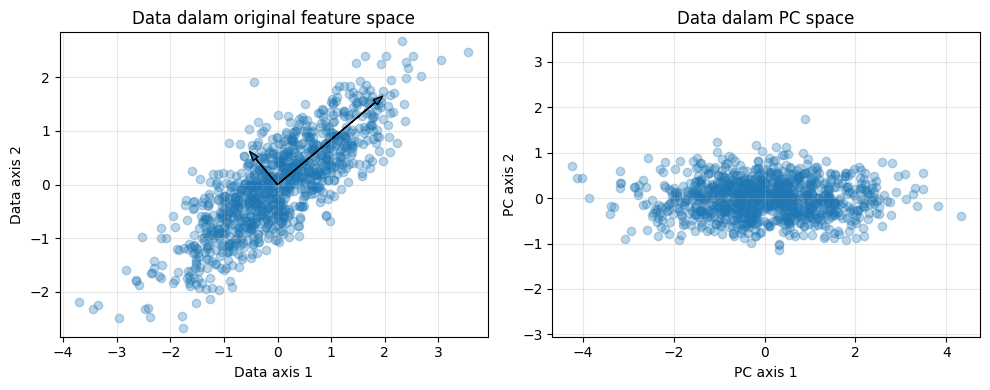

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(X[:, 0], X[:, 1], alpha=0.3)
for i in range(2):
    vec = evecs[:, i] * np.sqrt(evals[i]) * 2
    axes[0].arrow(0, 0, vec[0], vec[1], head_width=0.12, length_includes_head=True)
axes[0].set_title("Data dalam original feature space")
axes[0].set_xlabel("Data axis 1")
axes[0].set_ylabel("Data axis 2")
axes[0].axis("equal")
axes[0].grid(alpha=0.3)

axes[1].scatter(scores[:, 0], scores[:, 1], alpha=0.3)
axes[1].set_title("Data dalam PC space")
axes[1].set_xlabel("PC axis 1")
axes[1].set_ylabel("PC axis 2")
axes[1].axis("equal")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## PCA via SVD

Chapter menjelaskan bahwa PCA dapat dilakukan dengan dua cara menggunakan SVD:

1. SVD pada covariance matrix.
2. SVD langsung pada data matrix yang sudah mean-centered.

Jika menggunakan data matrix langsung, right singular vectors dari data matrix setara dengan eigenvectors dari covariance matrix. Perlu diingat bahwa eigenvalues dari $X^TX$ berkaitan dengan kuadrat singular values dari $X$.

In [4]:
# PCA via SVD langsung pada data matrix
U, s, Vt = np.linalg.svd(X, full_matrices=False)

scores_svd = X @ Vt.T
eigvals_svd = (s**2) / (X.shape[0]-1)
var_exp_svd = 100 * eigvals_svd / np.sum(eigvals_svd)

print("Variance explained via eigendecomposition:")
print(np.round(var_exp, 2))

print("\nVariance explained via SVD:")
print(np.round(var_exp_svd, 2))

print("\nCorrelation between first PCA score methods:")
print(np.corrcoef(scores[:, 0], scores_svd[:, 0])[0, 1])

Variance explained via eigendecomposition:
[90.89  9.11]

Variance explained via SVD:
[90.89  9.11]

Correlation between first PCA score methods:
-1.0


## Catatan tentang Interpretasi PCA

PCA sangat berguna untuk dimensionality reduction, data compression, data cleaning, dan stabilitas numerik. Namun, principal components harus diinterpretasikan hati-hati karena PCA memiliki constraint bahwa basis baru adalah orthogonal rotation dari basis awal.

Jika struktur data sebenarnya tidak cocok dengan constraint orthogonality, PCA tetap menghasilkan solusi matematis yang benar, tetapi basis vector-nya belum tentu paling natural untuk feature extraction.

## Linear Discriminant Analysis

Linear Discriminant Analysis atau LDA adalah teknik multivariate classification. Berbeda dari PCA yang mencari arah dengan variance terbesar, LDA mencari arah yang paling memisahkan kategori data.

Tujuan LDA adalah menemukan basis vector dalam data space sehingga kategori data menjadi lebih mudah dipisahkan secara linear.

## Rumus Tujuan LDA

Objective function LDA ditulis mirip dengan PCA, tetapi menggunakan rasio dua variance:

$$
\lambda =
\frac{\|X_Bw\|^2}{\|X_Ww\|^2}
$$

Keterangan:

- $X_B$ = data feature yang berkaitan dengan between-category covariance
- $X_W$ = data feature yang berkaitan dengan within-category covariance
- $w$ = weights vector
- $\lambda$ = variance ratio

Dalam implementasi LDA, numerator ingin dimaksimalkan dan denominator ingin diminimalkan. Artinya, LDA mencari arah yang membuat jarak antar kelas besar, tetapi variasi dalam kelas kecil.

## LDA sebagai Generalized Eigendecomposition

Chapter menunjukkan bahwa solusi LDA diperoleh melalui generalized eigendecomposition.

### Rumus LDA

$$
C_BW = C_WW\Lambda
$$

atau secara umum:

$$
C_Bw = \lambda C_Ww
$$

Keterangan:

- $C_B$ = between-class covariance matrix
- $C_W$ = within-class covariance matrix
- $W$ = matrix eigenvectors atau discriminant weights
- $\Lambda$ = generalized eigenvalues
- Eigenvectors menjadi weights untuk memproyeksikan data ke LDA space

Tidak seperti PCA, eigenvectors dari generalized eigendecomposition tidak harus orthogonal dalam ruang Euclidean biasa.

In [5]:
# Simulasi data LDA 2D seperti chapter
n_per_class = 200

class0 = np.random.randn(n_per_class, 2)
class0[:, 1] = class0[:, 1] + class0[:, 0]
class0 = class0 + np.array([2, -1])

class1 = np.random.randn(n_per_class, 2)
class1[:, 1] = class1[:, 1] + class1[:, 0]

X_lda = np.vstack((class0, class1))
labels = np.hstack((np.zeros(n_per_class), np.ones(n_per_class)))

# Mean-center per feature
X_lda_centered = X_lda - X_lda.mean(axis=0)

# Within-class covariance
C0 = np.cov(class0.T)
C1 = np.cov(class1.T)
Cw = (C0 + C1) / 2

# Between-class covariance
class_means = np.vstack((class0.mean(axis=0), class1.mean(axis=0)))
Cb = np.cov(class_means.T)

if SCIPY_AVAILABLE:
    evals_lda, evecs_lda = eigh(Cb, Cw)
    idx = np.argsort(evals_lda)[::-1]
    evals_lda = evals_lda[idx]
    evecs_lda = evecs_lda[:, idx]
else:
    # fallback sederhana menggunakan pseudo inverse
    evals_lda, evecs_lda = np.linalg.eig(np.linalg.pinv(Cw) @ Cb)
    idx = np.argsort(evals_lda)[::-1]
    evals_lda = evals_lda[idx]
    evecs_lda = evecs_lda[:, idx]

scores_lda = X_lda_centered @ evecs_lda

pred_labels = (scores_lda[:, 0] > 0).astype(int)

# Karena arah eigenvector bisa terbalik, pilih orientasi akurasi terbaik
acc1 = np.mean(pred_labels == labels)
acc2 = np.mean((1 - pred_labels) == labels)
accuracy = max(acc1, acc2)

print("Generalized eigenvalues:")
print(np.round(evals_lda, 4))
print("\nClassification accuracy:", round(accuracy*100, 2), "%")

Generalized eigenvalues:
[6.4104 0.    ]

Classification accuracy: 96.75 %


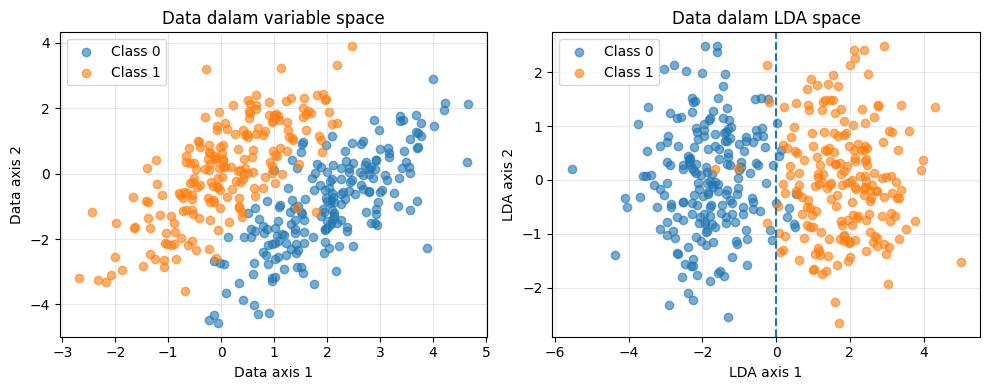

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(class0[:, 0], class0[:, 1], alpha=0.6, label="Class 0")
axes[0].scatter(class1[:, 0], class1[:, 1], alpha=0.6, label="Class 1")
axes[0].set_title("Data dalam variable space")
axes[0].set_xlabel("Data axis 1")
axes[0].set_ylabel("Data axis 2")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(scores_lda[labels == 0, 0], scores_lda[labels == 0, 1], alpha=0.6, label="Class 0")
axes[1].scatter(scores_lda[labels == 1, 0], scores_lda[labels == 1, 1], alpha=0.6, label="Class 1")
axes[1].axvline(0, linestyle="--")
axes[1].set_title("Data dalam LDA space")
axes[1].set_xlabel("LDA axis 1")
axes[1].set_ylabel("LDA axis 2")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## LDA dengan `sklearn`

Chapter exercises juga membandingkan LDA manual dengan implementasi `sklearn`. Library `sklearn` menyediakan `LinearDiscriminantAnalysis`, termasuk solver `eigen` yang sesuai dengan pendekatan generalized eigendecomposition.

In [7]:
if SKLEARN_AVAILABLE:
    lda_model = LinearDiscriminantAnalysis(solver="eigen")
    lda_model.fit(X_lda, labels)
    pred_sklearn = lda_model.predict(X_lda)

    sklearn_acc = np.mean(pred_sklearn == labels)

    print("sklearn LDA accuracy:", round(sklearn_acc*100, 2), "%")
else:
    print("scikit-learn tidak tersedia di environment ini.")

sklearn LDA accuracy: 96.75 %


## Shrinkage Regularization pada LDA

Chapter exercises menggunakan `sklearn` untuk mengeksplorasi shrinkage regularization pada LDA. Inti diskusinya adalah shrinkage tidak selalu meningkatkan performa. Pada training data, regularization biasanya menurunkan fit. Yang lebih penting adalah apakah shrinkage meningkatkan performa pada validation atau test set.

Chapter menunjukkan bahwa dalam contoh LDA tersebut, shrinkage cenderung berdampak negatif terhadap validation performance. Hal ini menekankan bahwa trik machine learning tidak selalu menguntungkan untuk semua dataset.

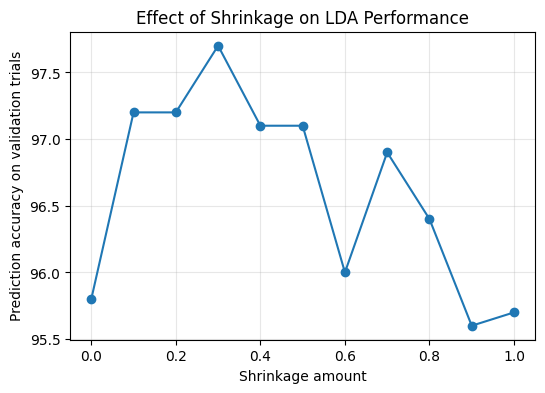

In [8]:
if SKLEARN_AVAILABLE:
    shrinkages = np.linspace(0, 1, 11)
    avg_acc = []

    for shrink in shrinkages:
        accs = []
        for _ in range(20):
            X_train, X_test, y_train, y_test = train_test_split(
                X_lda, labels, test_size=50, random_state=None, stratify=labels
            )
            model = LinearDiscriminantAnalysis(solver="eigen", shrinkage=shrink)
            model.fit(X_train, y_train)
            accs.append(model.score(X_test, y_test))
        avg_acc.append(np.mean(accs))

    plt.figure(figsize=(6, 4))
    plt.plot(shrinkages, np.array(avg_acc)*100, "o-")
    plt.xlabel("Shrinkage amount")
    plt.ylabel("Prediction accuracy on validation trials")
    plt.title("Effect of Shrinkage on LDA Performance")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("scikit-learn tidak tersedia di environment ini.")

## Low-Rank Approximations via SVD

Low-rank approximation adalah proses merekonstruksi matrix menggunakan sebagian singular vectors dan singular values. Jika hanya $k$ komponen pertama yang dipakai, maka hasil rekonstruksi memiliki rank maksimal $k$.

### Rumus Low-Rank Approximation

$$
\tilde{A}_k =
U_k\Sigma_kV_k^T
$$

Keterangan:

- $\tilde{A}_k$ = matrix rekonstruksi rank-$k$
- $U_k$ = $k$ left singular vectors pertama
- $\Sigma_k$ = $k$ singular values pertama
- $V_k^T$ = $k$ right singular vectors pertama

Low-rank approximation dapat digunakan untuk data compression karena tidak perlu menyimpan seluruh matrix asli.

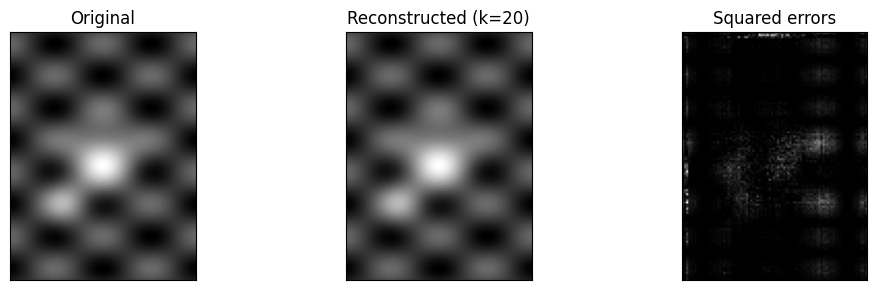

In [9]:
# Simulasi "image" 2D sederhana untuk low-rank approximation
m, n = 120, 90
Y, Xgrid = np.meshgrid(np.linspace(-3, 3, n), np.linspace(-4, 4, m))

img = (
    np.exp(-(Xgrid**2 + Y**2)) +
    0.5*np.exp(-((Xgrid-1.5)**2 + (Y+1.2)**2)*2) +
    0.3*np.sin(3*Xgrid)*np.cos(2*Y)
)

U, s, Vt = np.linalg.svd(img, full_matrices=False)

k = 20
img_k = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
error_map = (img - img_k)**2

fig, axes = plt.subplots(1, 3, figsize=(11, 3))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(img_k, cmap="gray")
axes[1].set_title(f"Reconstructed (k={k})")

axes[2].imshow(error_map, cmap="gray")
axes[2].set_title("Squared errors")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Compression Ratio

Chapter menghitung compression ratio dengan membandingkan jumlah data yang perlu disimpan pada low-rank approximation terhadap ukuran matrix asli.

Untuk menyimpan rank-$k$ approximation, yang perlu disimpan adalah:

- $U_k$
- $\Sigma_k$
- $V_k^T$

Secara konsep:

$$
\text{compression ratio}
=
\frac{\text{size of }U_k+\Sigma_k+V_k^T}{\text{size of original matrix}}
\times 100\%
$$

In [10]:
original_size = img.size
compressed_size = (m*k) + k + (k*n)
compression_ratio = 100 * compressed_size / original_size

print("Original values:", original_size)
print("Compressed values:", compressed_size)
print(f"Compression ratio: {compression_ratio:.2f}%")

Original values: 10800
Compressed values: 4220
Compression ratio: 39.07%


## Error sebagai Fungsi Rank

Chapter menekankan bahwa semakin besar $k$, reconstruction error akan semakin kecil. Namun, tidak selalu ada satu nilai $k$ yang jelas paling tepat. Kadang derivative dari error curve lebih informatif daripada error mentah.

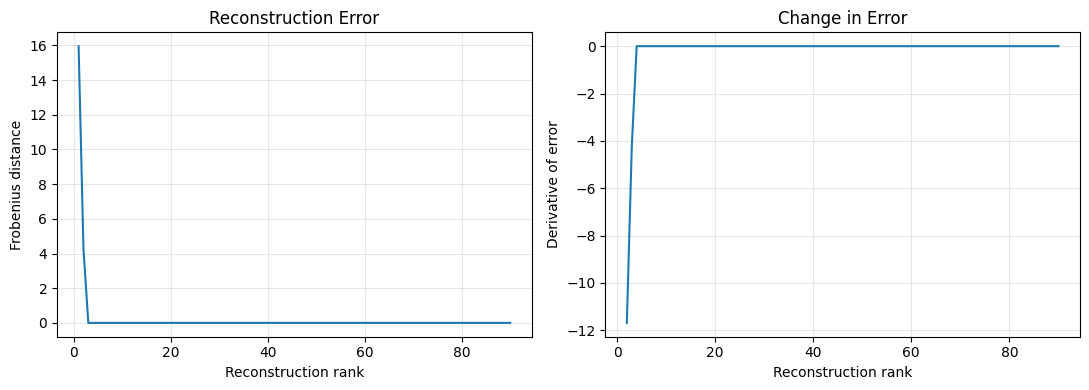

In [11]:
ranks = np.arange(1, min(img.shape)+1)
errors = []

for rank in ranks:
    approx = U[:, :rank] @ np.diag(s[:rank]) @ Vt[:rank, :]
    errors.append(np.linalg.norm(img - approx, "fro"))

errors = np.array(errors)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(ranks, errors)
axes[0].set_xlabel("Reconstruction rank")
axes[0].set_ylabel("Frobenius distance")
axes[0].set_title("Reconstruction Error")
axes[0].grid(alpha=0.3)

axes[1].plot(ranks[1:], np.diff(errors))
axes[1].set_xlabel("Reconstruction rank")
axes[1].set_ylabel("Derivative of error")
axes[1].set_title("Change in Error")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## SVD for Denoising

Denoising via SVD adalah aplikasi dari low-rank approximation. Perbedaannya, komponen yang dihapus bukan hanya komponen kecil, tetapi komponen yang dianggap merepresentasikan noise atau artifact.

Chapter memberi contoh noise berupa 2D sine grating yang ditambahkan ke image. Jika noise dominan muncul pada beberapa komponen SVD tertentu, komponen tersebut dapat dihilangkan dari rekonstruksi.

## Rumus 2D Sine Grating

Noise yang digunakan pada chapter berbentuk sine grating 2D:

$$
Z =
\sin
\left(
2\pi f
\left(
X\cos(\theta)+Y\sin(\theta)
\right)
\right)
$$

Keterangan:

- $Z$ = noise image
- $f$ = frequency
- $\theta$ = rotation parameter
- $X$ dan $Y$ = grid lokasi
- $\pi$ = konstanta pi

Chapter menggunakan contoh parameter $f=.02$ dan $\theta=\pi/6$.

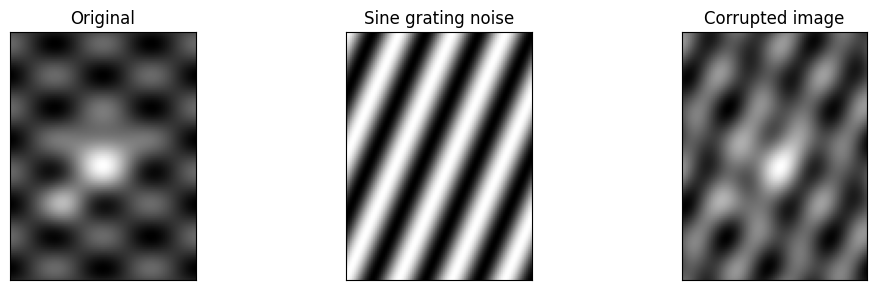

In [12]:
# Buat sine grating noise
rows, cols = img.shape

xvals = np.linspace(-100, 100, cols)
yvals = np.linspace(-100, 100, rows)
Xg, Yg = np.meshgrid(xvals, yvals)

f = 0.02
theta = np.pi / 6

noise = np.sin(2*np.pi*f*(Xg*np.cos(theta) + Yg*np.sin(theta)))

corrupted = img + 0.35*noise

fig, axes = plt.subplots(1, 3, figsize=(11, 3))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(noise, cmap="gray")
axes[1].set_title("Sine grating noise")

axes[2].imshow(corrupted, cmap="gray")
axes[2].set_title("Corrupted image")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Menghapus Komponen Noise

Pada chapter, noise tampak terkandung pada beberapa komponen SVD tertentu. Ide denoising-nya adalah merekonstruksi image menggunakan semua komponen kecuali komponen yang dianggap noise.

Contoh berikut menghapus komponen 1 dan 2 secara sederhana. Hasilnya tidak selalu sempurna karena noise biasanya tidak seluruhnya terkandung dalam satu atau dua dimensi.

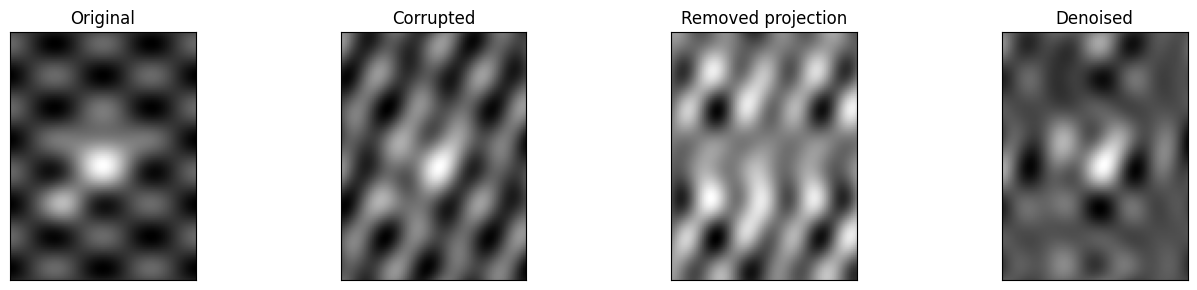

In [13]:
U_c, s_c, Vt_c = np.linalg.svd(corrupted, full_matrices=False)

# Rekonstruksi full kemudian hilangkan beberapa komponen yang diasumsikan membawa noise
components_to_remove = [1, 2]

s_denoised = s_c.copy()
s_denoised[components_to_remove] = 0

denoised = U_c @ np.diag(s_denoised) @ Vt_c

noise_projection = corrupted - denoised

fig, axes = plt.subplots(1, 4, figsize=(14, 3))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(corrupted, cmap="gray")
axes[1].set_title("Corrupted")

axes[2].imshow(noise_projection, cmap="gray")
axes[2].set_title("Removed projection")

axes[3].imshow(denoised, cmap="gray")
axes[3].set_title("Denoised")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Catatan tentang Denoising

Chapter menekankan bahwa denoising SVD tidak selalu sempurna. Ada beberapa alasan:

- Noise tidak selalu terkandung hanya pada satu atau dua komponen.
- Komponen noise dapat tercampur dengan struktur signal asli.
- Noise projection dapat memiliki nilai negatif dan tersebar di sekitar nol.
- Rekonstruksi tetap harus menyeimbangkan signal asli dan artifact yang dihapus.

Dengan kata lain, SVD dapat membantu denoising, tetapi tidak otomatis memberikan hasil sempurna tanpa analisis komponen.

## Ringkasan Konsep Penting

| Konsep | Ringkasan |
|---|---|
| PCA | Metode mencari basis baru yang memaksimalkan variance. |
| Variance = relevance | Asumsi PCA bahwa arah dengan variance besar lebih penting. |
| PCA eigendecomposition | PCA diperoleh dari eigendecomposition covariance matrix. |
| Principal components | Weighted combination dari fitur data. |
| PCA via SVD | PCA dapat dilakukan melalui SVD covariance matrix atau data matrix. |
| LDA | Metode linear untuk memisahkan kategori data. |
| Between-class covariance | Covariance yang ingin dimaksimalkan oleh LDA. |
| Within-class covariance | Covariance yang ingin diminimalkan oleh LDA. |
| Generalized eigendecomposition | Bentuk $C_Bw=\lambda C_Ww$. |
| Shrinkage | Regularization pada LDA yang tidak selalu meningkatkan performa. |
| Low-rank approximation | Rekonstruksi matrix dengan sebagian singular components. |
| Compression ratio | Ukuran seberapa kecil representasi low-rank dibanding matrix asli. |
| SVD denoising | Menghapus komponen SVD yang dianggap merepresentasikan noise. |

## Kesimpulan Chapter

Chapter ini menutup pembahasan linear algebra dengan memperlihatkan aplikasi nyata eigendecomposition dan SVD dalam data science. PCA digunakan untuk mencari basis baru yang memaksimalkan variance data. Secara matematis, PCA diselesaikan melalui eigendecomposition covariance matrix atau melalui SVD pada covariance/data matrix.

LDA digunakan untuk classification. Jika PCA memaksimalkan variance secara umum, LDA memaksimalkan separasi antar kelas dengan membandingkan between-class covariance dan within-class covariance. Solusinya diperoleh melalui generalized eigendecomposition.

SVD digunakan untuk low-rank approximation. Dengan menyimpan sebagian singular vectors dan singular values, matrix atau image dapat direkonstruksi dalam ukuran lebih kecil. Prinsip ini menjadi dasar compression, meskipun image compression modern seperti JPG menggunakan pendekatan yang lebih kompleks.

SVD juga dapat digunakan untuk denoising. Komponen yang dianggap merepresentasikan noise atau artifact dapat dihapus dari rekonstruksi. Namun, hasilnya tidak selalu sempurna karena noise sering bercampur dengan signal asli.

Secara keseluruhan, chapter ini menunjukkan bahwa eigendecomposition dan SVD bukan hanya konsep teoritis, tetapi merupakan fondasi penting untuk PCA, LDA, compression, denoising, dimensionality reduction, dan berbagai metode machine learning modern.